In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('adult_with_headers (1).csv')
df.shape

(32561, 15)

In [3]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


#### Handle missing values as per the best practices (imputation, removal, etc.).

In [5]:
df.isna().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

there are no missing/ Null values in the dataset

#### Apply scaling techniques to numerical features:

- Many machine learning algorithms treat features equally by default.
- If one feature has much larger values than another, it can dominate distance-based models and gradient-based training.

In [6]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [7]:
# seperate numerical data
df_num = df[['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']]


In [8]:
# Standard scaler (z-score)
from sklearn.preprocessing import StandardScaler

In [9]:
ss = StandardScaler()

In [ ]:
ss_df_num = ss.fit_transform(df_num)
ss_df_num = pd.DataFrame(ss_df_num)
ss_df_num.columns = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
ss_df_num.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429


- Transforms values to have mean = 0 and standard deviation = 1.
- Good for algorithms like linear regression, logistic regression, SVM, k-NN, PCA

In [11]:
# normalization scaling (minmax)
from sklearn.preprocessing import MinMaxScaler

In [12]:
mm = MinMaxScaler()

In [13]:
mm_df_num = mm.fit_transform(df_num)
mm_df_num = pd.DataFrame(mm_df_num)
mm_df_num.columns = ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']
mm_df_num.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
0,0.301370,0.044302,0.800000,0.02174,0.0,0.397959
1,0.452055,0.048238,0.800000,0.00000,0.0,0.122449
2,0.287671,0.138113,0.533333,0.00000,0.0,0.397959
3,0.493151,0.151068,0.400000,0.00000,0.0,0.397959
4,0.150685,0.221488,0.800000,0.00000,0.0,0.397959


- Scales values to a fixed range, usually 0 to 1, but Preserves the shape of the original distribution.
- Useful when you need bounded input values.

#### 2. Encoding Techniques:

In [14]:
df_cat = df[['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'native_country', 'income']]
df_cat.head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,State-gov,Bachelors,Never-married,Adm-clerical,Not-in-family,White,Male,United-States,<=50K
1,Self-emp-not-inc,Bachelors,Married-civ-spouse,Exec-managerial,Husband,White,Male,United-States,<=50K
2,Private,HS-grad,Divorced,Handlers-cleaners,Not-in-family,White,Male,United-States,<=50K
3,Private,11th,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,United-States,<=50K
4,Private,Bachelors,Married-civ-spouse,Prof-specialty,Wife,Black,Female,Cuba,<=50K


- there are some missing values '?' in these column
- handeled it with by Create a New Category "Unknown"  

In [15]:
# inspect what's actually stored
df_cat['native_country'].value_counts(dropna=False).head(20)
df_cat.loc[df_cat['native_country'].astype(str).str.strip().str.contains(r'\?', na=False), 'native_country'].unique()

array([' ?'], dtype=object)

In [16]:
df_cat['native_country'] = df_cat['native_country'].replace(' ?', np.nan)
df_cat['native_country'].isna().sum()


C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_26540\380746174.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cat['native_country'] = df_cat['native_country'].replace(' ?', np.nan)


np.int64(583)

In [17]:
df_cat['workclass'] = df_cat['workclass'].replace(' ?', np.nan)
df_cat['workclass'].isna().sum()

C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_26540\2280316646.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cat['workclass'] = df_cat['workclass'].replace(' ?', np.nan)


np.int64(1836)

In [18]:
df_cat['occupation'] = df_cat['occupation'].replace(' ?', np.nan)
df_cat['occupation'].isna().sum()

C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_26540\3606033434.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cat['occupation'] = df_cat['occupation'].replace(' ?', np.nan)


np.int64(1843)

In [19]:
df_cat['native_country'].fillna('Unknown', inplace=True)
df_cat['workclass'].fillna('Unknown', inplace=True)
df_cat['occupation'].fillna('Unknown', inplace=True)

C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_26540\4005835906.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_cat['native_country'].fillna('Unknown', inplace=True)
C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_26540\4005835906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cat['native_country'].fillna('Unknown', inplace

In [20]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [21]:
df_cat['workclass'] = le.fit_transform(df_cat['workclass'])
df_cat['marital_status'] = le.fit_transform(df_cat['marital_status'])
df_cat['occupation'] = le.fit_transform(df_cat['occupation'])
df_cat['relationship'] = le.fit_transform(df_cat['relationship'])
df_cat['race'] = le.fit_transform(df_cat['race'])
df_cat['native_country'] = le.fit_transform(df_cat['native_country'])   

C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_26540\3109149440.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cat['workclass'] = le.fit_transform(df_cat['workclass'])
C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_26540\3109149440.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cat['marital_status'] = le.fit_transform(df_cat['marital_status'])
C:\Users\Basavaraj M\AppData\Local\Temp\ipykernel_26540\3109149440.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a sli

In [22]:
df_cat.head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income
0,6,Bachelors,4,0,1,4,Male,38,<=50K
1,5,Bachelors,2,3,0,4,Male,38,<=50K
2,3,HS-grad,0,5,1,4,Male,38,<=50K
3,3,11th,2,5,0,2,Male,38,<=50K
4,3,Bachelors,2,9,5,2,Female,4,<=50K


- Assigns a unique integer to each category.
- Advantages
  - Simple
  - Memory efficient
- Disadvantages
  - Creates an artificial order
  - Not suitable for nominal variables

In [23]:
# one hot encoding
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder()

In [24]:
df_g = pd.DataFrame(ohe.fit_transform(df_cat[["sex"]]).toarray())
df_g.columns = ["females", "males"]
df_g.head()

,females,males
0,0.0,1.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0


In [25]:
df_cat = pd.concat([df_cat, df_g], axis=1)
df_cat.head()

,workclass,education,marital_status,occupation,relationship,race,sex,native_country,income,females,males
0,6,Bachelors,4,0,1,4,Male,38,<=50K,0.0,1.0
1,5,Bachelors,2,3,0,4,Male,38,<=50K,0.0,1.0
2,3,HS-grad,0,5,1,4,Male,38,<=50K,0.0,1.0
3,3,11th,2,5,0,2,Male,38,<=50K,0.0,1.0
4,3,Bachelors,2,9,5,2,Female,4,<=50K,1.0,0.0


In [26]:
df_cat.drop(columns=['sex'], inplace=True)
df_cat.head()

,workclass,education,marital_status,occupation,relationship,race,native_country,income,females,males
0,6,Bachelors,4,0,1,4,38,<=50K,0.0,1.0
1,5,Bachelors,2,3,0,4,38,<=50K,0.0,1.0
2,3,HS-grad,0,5,1,4,38,<=50K,0.0,1.0
3,3,11th,2,5,0,2,38,<=50K,0.0,1.0
4,3,Bachelors,2,9,5,2,4,<=50K,1.0,0.0


- Creates a separate binary column for each category.
- Advantages
  - No artificial ordering
  - Works well for nominal data
- Disadvantages
  - Creates many columns
  - Can cause high dimensionality

In [27]:
# Ordinal Encoding on 'education'
df_cat['education'].unique() 

array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th',
       ' Preschool', ' 12th'], dtype=object)

In [28]:
education_map = {
    ' Preschool': 0,
    ' 1st-4th': 1,
    ' 5th-6th': 2,
    ' 7th-8th': 3,
    ' 9th': 4,
    ' 10th': 5,
    ' 11th': 6,
    ' 12th': 7,
    ' HS-grad': 8,
    ' Some-college': 9,
    ' Assoc-voc': 10,
    ' Assoc-acdm': 11,
    ' Bachelors': 12,
    ' Masters': 13,
    ' Prof-school': 14,
    ' Doctorate': 15
}

df_cat['education'] = df_cat['education'].map(education_map)

In [29]:
df_cat['income'].unique()

array([' <=50K', ' >50K'], dtype=object)

In [30]:
df_cat['income'] = df_cat['income'].map({
    ' <=50K': 0,
    ' >50K': 1
})

- Used when categories have a natural order.
- Advantages
  - Preserves ranking information
- Disadvantages
  - Distance between categories may not be meaningful

In [32]:
df_cat.head()

,workclass,education,marital_status,occupation,relationship,race,native_country,income,females,males
0,6,12,4,0,1,4,38,0,0.0,1.0
1,5,12,2,3,0,4,38,0,0.0,1.0
2,3,8,0,5,1,4,38,0,0.0,1.0
3,3,6,2,5,0,2,38,0,0.0,1.0
4,3,12,2,9,5,2,4,0,1.0,0.0


#### 3. Feature Engineering:

In [33]:
# first combine both dataframe
df_new = pd.concat([ss_df_num, df_cat], axis=1)
df_new.head()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,workclass,education,marital_status,occupation,relationship,race,native_country,income,females,males
0,0.030671,-1.063611,1.134739,0.148453,-0.21666,-0.035429,6,12,4,0,1,4,38,0,0.0,1.0
1,0.837109,-1.008707,1.134739,-0.145920,-0.21666,-2.222153,5,12,2,3,0,4,38,0,0.0,1.0
2,-0.042642,0.245079,-0.420060,-0.145920,-0.21666,-0.035429,3,8,0,5,1,4,38,0,0.0,1.0
3,1.057047,0.425801,-1.197459,-0.145920,-0.21666,-0.035429,3,6,2,5,0,2,38,0,0.0,1.0
4,-0.775768,1.408176,1.134739,-0.145920,-0.21666,-0.035429,3,12,2,9,5,2,4,0,1.0,0.0


In [34]:
df['experience_score'] = (
    df['age'] *
    df['education_num']
)

Individuals who are older and possess higher educational qualifications are generally more likely to earn higher incomes. The experience_score feature helps the model capture this interaction between age and education, which may not be fully represented when the variables are considered separately.

In [35]:
df['net_capital'] = (
    df['capital_gain'] -
    df['capital_loss']
)

The net_capital feature represents an individual's overall financial gain after accounting for losses. A higher net capital value may indicate greater wealth or investment success, which can be strongly associated with higher income levels. This feature provides a more comprehensive view of financial performance than using capital gain and capital loss separately.

In [36]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,experience_score,net_capital
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,507,2174
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,650,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,342,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,371,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,364,0


Feature engineering was performed on the original variables before scaling and encoding. The newly created features were then included in the preprocessing pipeline along with the existing features.

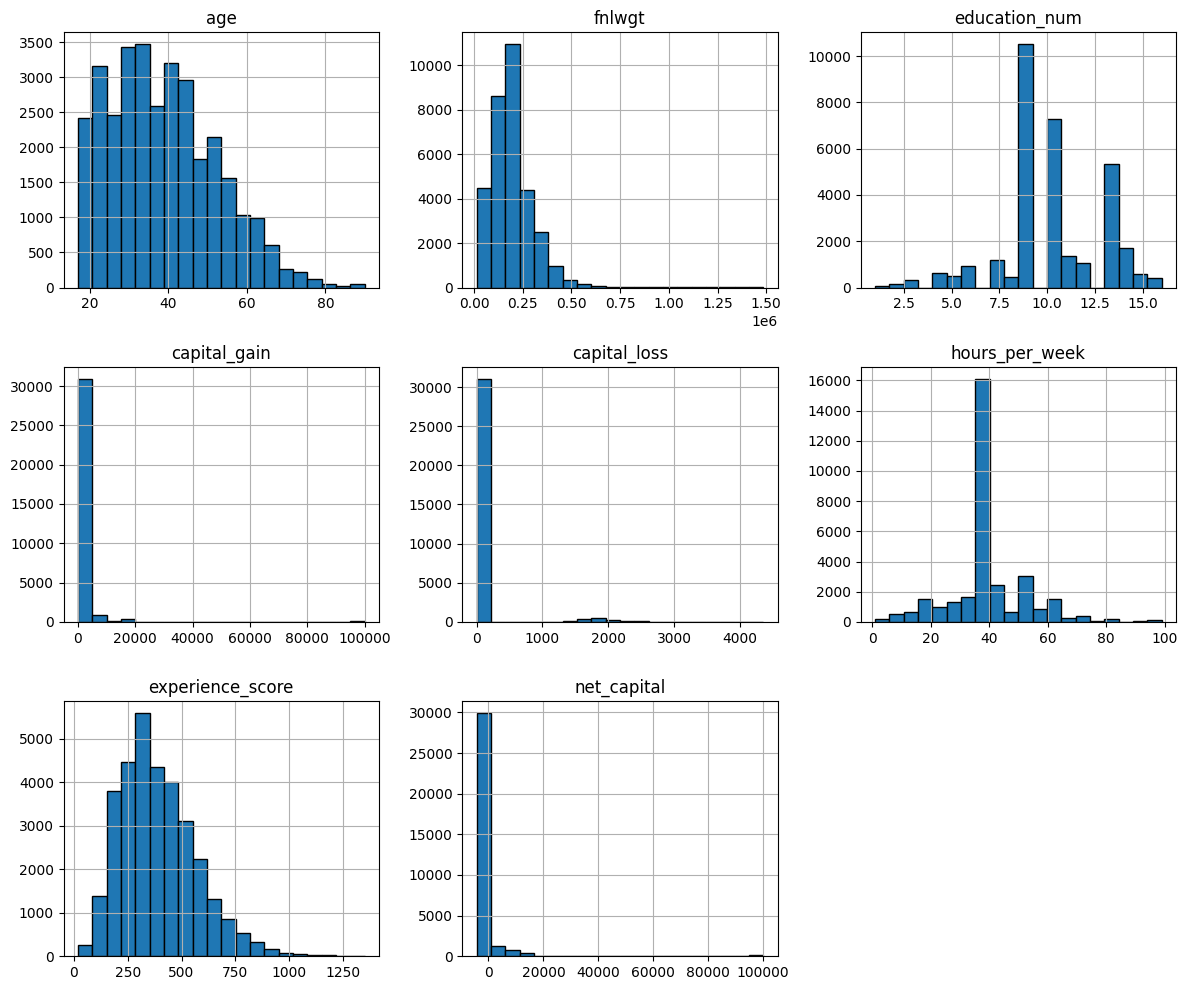

In [37]:
df.hist(figsize=(12, 10), bins=20, edgecolor='black')

# Adjust layout to prevent label overlap
plt.tight_layout()
plt.show()

we can see that 'fnlwgt' is right skewed, we will apply log transformation on that

In [38]:
# Apply log transformation
df['fnlwgt'] = np.log1p(df['fnlwgt'])

In [39]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income,experience_score,net_capital
0,39,State-gov,11.258253,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,507,2174
1,50,Self-emp-not-inc,11.330348,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,650,0
2,38,Private,12.281398,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,342,0
3,53,Private,12.366157,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,371,0
4,28,Private,12.732013,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,364,0


In [40]:
df_featured_scaling = df[["fnlwgt", "experience_score", "net_capital"]]

In [41]:
ss_df_featured_scaling = ss.fit_transform(df_featured_scaling)
ss_df_featured_scaling = pd.DataFrame(ss_df_featured_scaling)
ss_df_featured_scaling.columns = ["fnlwgt", "experience_score", "net_capital"]
ss_df_featured_scaling.head()

,fnlwgt,experience_score,net_capital
0,-1.150298,0.662489,0.159762
1,-1.035993,1.473661,-0.133670
2,0.471867,-0.273478,-0.133670
3,0.606250,-0.108975,-0.133670
4,1.186304,-0.148683,-0.133670


In [42]:
df_new.drop(columns=['fnlwgt'], inplace=True)
df_new.head()

,age,education_num,capital_gain,capital_loss,hours_per_week,workclass,education,marital_status,occupation,relationship,race,native_country,income,females,males
0,0.030671,1.134739,0.148453,-0.21666,-0.035429,6,12,4,0,1,4,38,0,0.0,1.0
1,0.837109,1.134739,-0.145920,-0.21666,-2.222153,5,12,2,3,0,4,38,0,0.0,1.0
2,-0.042642,-0.420060,-0.145920,-0.21666,-0.035429,3,8,0,5,1,4,38,0,0.0,1.0
3,1.057047,-1.197459,-0.145920,-0.21666,-0.035429,3,6,2,5,0,2,38,0,0.0,1.0
4,-0.775768,1.134739,-0.145920,-0.21666,-0.035429,3,12,2,9,5,2,4,0,1.0,0.0


In [43]:
df_new = pd.concat([df_new, ss_df_featured_scaling], axis=1)
df_new.head()

,age,education_num,capital_gain,capital_loss,hours_per_week,workclass,education,marital_status,occupation,relationship,race,native_country,income,females,males,fnlwgt,experience_score,net_capital
0,0.030671,1.134739,0.148453,-0.21666,-0.035429,6,12,4,0,1,4,38,0,0.0,1.0,-1.150298,0.662489,0.159762
1,0.837109,1.134739,-0.145920,-0.21666,-2.222153,5,12,2,3,0,4,38,0,0.0,1.0,-1.035993,1.473661,-0.133670
2,-0.042642,-0.420060,-0.145920,-0.21666,-0.035429,3,8,0,5,1,4,38,0,0.0,1.0,0.471867,-0.273478,-0.133670
3,1.057047,-1.197459,-0.145920,-0.21666,-0.035429,3,6,2,5,0,2,38,0,0.0,1.0,0.606250,-0.108975,-0.133670
4,-0.775768,1.134739,-0.145920,-0.21666,-0.035429,3,12,2,9,5,2,4,0,1.0,0.0,1.186304,-0.148683,-0.133670
